In [11]:

# 1. Clone the StyleGAN2-ADA repository
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
%cd stylegan2-ada-pytorch 

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 25.73 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/kaggle/working/stylegan2-ada-pytorch


In [12]:
%cd /kaggle/working/stylegan2-ada-pytorch

!python dataset_tool.py \
  --source=/kaggle/input/datasets/anil701/oraldatarwa \
  --dest=/kaggle/working/orchid_conditional_512.zip \
  --width=512 \
  --height=512

/kaggle/working/stylegan2-ada-pytorch
^C

Aborted!


In [3]:
!ls -lh /kaggle/working/orchid_conditional_512.zip

-rw-r--r-- 1 root root 7.6G Aug  9 07:34 /kaggle/working/orchid_conditional_512.zip


In [6]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
!pip install huggingface_hub matplotlib pillow pandas seaborn

fatal: destination path 'stylegan2-ada-pytorch' already exists and is not an empty directory.


In [7]:
from huggingface_hub import snapshot_download
import os

repo_id = "Anil701/anilorchid"
checkpoint_dir = "./downloaded_checkpoints"

# Pass your Hugging Face token to authenticate for private repository access
HF_TOKEN = "YOUR_HF_TOKEN_HERE"

snapshot_download(
    repo_id=repo_id, 
    repo_type="dataset", 
    local_dir=checkpoint_dir,
    token=HF_TOKEN
)

print("Successfully downloaded files:")
print(os.listdir(checkpoint_dir))

Fetching 39 files:   0%|          | 0/39 [00:00<?, ?it/s]

Successfully downloaded files:
['fakes_init.png', 'fakes001200.png', 'network-snapshot-000600.pkl', 'network-snapshot-003000.pkl', 'network-snapshot-002200.pkl', 'network-snapshot-001400.pkl', 'fakes000400.png', 'network-snapshot-001800.pkl', 'fakes002400.png', 'fakes001600.png', 'network-snapshot-001000.pkl', 'fakes000200.png', 'network-snapshot-000200.pkl', 'fakes002200.png', 'fakes001800.png', 'network-snapshot-000400.pkl', 'log.txt', 'fakes002000.png', 'fakes001000.png', 'network-snapshot-001600.pkl', 'network-snapshot-000800.pkl', 'fakes000800.png', 'reals.png', 'events.out.tfevents.1786098501.61c2de648809.1407.0', 'network-snapshot-001200.pkl', 'fakes002800.png', 'fakes000600.png', 'network-snapshot-002600.pkl', 'fakes003000.png', 'fakes000000.png', 'network-snapshot-002800.pkl', 'network-snapshot-002400.pkl', '.cache', 'network-snapshot-000000.pkl', 'fakes001400.png', 'training_options.json', 'fakes002600.png', 'stats.jsonl', 'network-snapshot-002000.pkl', '.gitattributes']


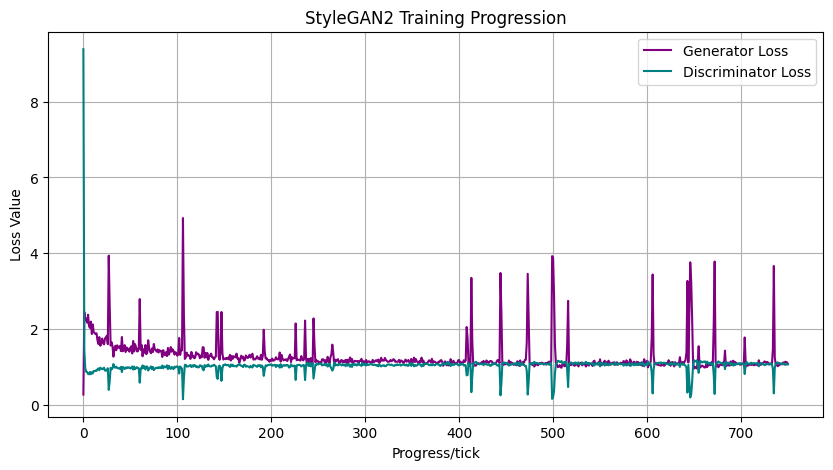

In [27]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load stats.jsonl
stats_file = os.path.join(checkpoint_dir, "stats.jsonl")

data = []
if os.path.exists(stats_file):
    with open(stats_file, 'r') as f:
        for line in f:
            data.append(json.loads(line))

df = pd.DataFrame(data)

# Helper function to extract the numeric 'mean' value from StyleGAN2's stat dictionaries
def extract_val(x):
    if isinstance(x, dict):
        return x.get('mean', x.get('value', 0))
    return x

# Clean up all columns in the dataframe so Matplotlib can read them
for col in df.columns:
    df[col] = df[col].apply(extract_val)

# Intelligently find the right X-axis column
if 'Progress/tick' in df.columns:
    x_axis = 'Progress/tick'
elif 'Progress/kimg' in df.columns:
    x_axis = 'Progress/kimg'
else:
    df['row_index'] = df.index
    x_axis = 'row_index'

# Plot Discriminator / Generator Loss over time
plt.figure(figsize=(10, 5))

# Check for Generator Loss
if 'Loss/G/loss' in df.columns:
    plt.plot(df[x_axis], df['Loss/G/loss'], label='Generator Loss', color='purple')

# Check for Discriminator Loss
if 'Loss/D/loss' in df.columns:
    plt.plot(df[x_axis], df['Loss/D/loss'], label='Discriminator Loss', color='teal')

plt.title('StyleGAN2 Training Progression')
plt.xlabel(x_axis)
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
!sed -i 's/super().__init__(dataset)/super().__init__()/g' /kaggle/working/stylegan2-ada-pytorch/torch_utils/misc.py

In [23]:
!echo "enabled = True" >> /kaggle/working/stylegan2-ada-pytorch/torch_utils/ops/grid_sample_gradfix.py

In [24]:
# Patching the DDP consistency check for PyTorch 2.x
file_path = '/kaggle/working/stylegan2-ada-pytorch/training/training_loop.py'

with open(file_path, 'r') as file:
    content = file.read()
    
# Tell the checker to ignore both 'w_avg' and 'noise_const'
content = content.replace(r"ignore_regex=r'.*\.w_avg'", r"ignore_regex=r'.*\.(w_avg|noise_const)'")

with open(file_path, 'w') as file:
    file.write(content)
    
print("Successfully patched training_loop.py for multi-GPU noise_const synchronization!")

Successfully patched training_loop.py for multi-GPU noise_const synchronization!


In [25]:
import re

file_path = '/kaggle/working/stylegan2-ada-pytorch/torch_utils/custom_ops.py'

with open(file_path, 'r') as file:
    content = file.read()

# Target and silence the hardcoded print statements
content = re.sub(r"print\(f'Setting up PyTorch plugin.*?\)", "pass", content)
content = re.sub(r"print\('Failed!'\)", "pass", content)
content = re.sub(r"print\('Done.'\)", "pass", content)

with open(file_path, 'w') as file:
    file.write(content)

print("NVIDIA plugin print statements successfully silenced!")

NVIDIA plugin print statements successfully silenced!


In [28]:
import os
import glob
import subprocess
import sys

# 🛑 THE FIX: Tell Python to completely silence all warning messages and tracebacks
os.environ["PYTHONWARNINGS"] = "ignore"

# Absolute paths
repo_dir = "/kaggle/working/stylegan2-ada-pytorch"
checkpoint_dir = f"{repo_dir}/downloaded_checkpoints"
dataset_zip = "/kaggle/working/orchid_conditional_512.zip"

# Find all the .pkl files
pkl_files = sorted(glob.glob(f"{checkpoint_dir}/*.pkl"))
print(f"Found {len(pkl_files)} checkpoints. Starting clean FID evaluation...")

# Loop through and calculate metrics for each checkpoint
for pkl in pkl_files:
    snapshot_name = os.path.basename(pkl)
    print(f"\n{'='*70}")
    print(f"🚀 Calculating fid50k_full for {snapshot_name} on 2 GPUs...")
    print(f"{'='*70}")
    
    # The StyleGAN2 metrics command
    cmd = (
        f"cd {repo_dir} && python calc_metrics.py "
        f"--metrics=fid50k_full "
        f"--gpus=2 "
        f"--network={pkl} "
        f"--data={dataset_zip}"
    )
    
    # Run the process
    process = subprocess.Popen(
        cmd, 
        shell=True, 
        stdout=subprocess.PIPE, 
        stderr=subprocess.STDOUT, 
        text=True
    )
    
    # Stream the clean output line-by-line
    for line in process.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
        
    process.wait()

print("\n✅ All FID calculations complete! Check the metric-fid50k_full.jsonl file.")

Found 16 checkpoints. Starting clean FID evaluation...

🚀 Calculating fid50k_full for network-snapshot-000000.pkl on 2 GPUs...
Loading network from "/kaggle/working/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-000000.pkl"...
Dataset options:
{
  "class_name": "training.dataset.ImageFolderDataset",
  "path": "/kaggle/working/orchid_conditional_512.zip",
  "resolution": 512,
  "use_labels": true
}
Launching processes...

Generator             Parameters  Buffers  Output shape        Datatype
---                   ---         ---      ---                 ---     
mapping.embed         3072        -        [1, 512]            float32 
mapping.fc0           524800      -        [1, 512]            float32 
mapping.fc1           262656      -        [1, 512]            float32 
mapping.fc2           262656      -        [1, 512]            float32 
mapping.fc3           262656      -        [1, 512]            float32 
mapping.fc4           262656      -        [1, 512]     

KeyboardInterrupt: 

In [ ]:
# !python -W ignore train.py \
#   --outdir=/kaggle/working/training-runs \
#   --data=/kaggle/working/orchid_conditional_512.zip \
#   --cond=1 \
#   --gpus=2 \
#   --cfg=auto \
#   --augpipe=color \
#   --mirror=1 \
#   --metrics=fid50k_full \
#   --snap=39 \
#   --resume=/kaggle/input/datasets/anil701/oralcheck156/network-snapshot-000156.pkl 


Training options:
{
  "num_gpus": 2,
  "image_snapshot_ticks": 39,
  "network_snapshot_ticks": 39,
  "metrics": [
    "fid50k_full"
  ],
  "random_seed": 0,
  "training_set_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "/kaggle/working/orchid_conditional_512.zip",
    "use_labels": true,
    "max_size": 10228,
    "xflip": true,
    "resolution": 512
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 3,
    "prefetch_factor": 2
  },
  "G_kwargs": {
    "class_name": "training.networks.Generator",
    "z_dim": 512,
    "w_dim": 512,
    "mapping_kwargs": {
      "num_layers": 2
    },
    "synthesis_kwargs": {
      "channel_base": 32768,
      "channel_max": 512,
      "num_fp16_res": 4,
      "conv_clamp": 256
    }
  },
  "D_kwargs": {
    "class_name": "training.networks.Discriminator",
    "block_kwargs": {},
    "mapping_kwargs": {},
    "epilogue_kwargs": {
      "mbstd_group_size": 4
    },
    "channel_base": 32768,
    

In [8]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

model_path = "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"

for i in range(5):  # Classes 0 to 4
    cmd = (
        f"python /kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/generate.py "
        f"--outdir=out_class_sweep "
        f"--trunc=1 "
        f"--seeds=42 "
        f"--class={i} "
        f"--network={model_path}"
    )
    print(f"Generating image for class {i}...")
    os.system(cmd)

print("Class sweep complete! Check your 'out_class_sweep' directory.")

Generating image for class 0...
Loading networks from "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"...
Generating image for seed 42 (0/1) ...
Generating image for class 1...
Loading networks from "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"...
Generating image for seed 42 (0/1) ...
Generating image for class 2...
Loading networks from "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"...
Generating image for seed 42 (0/1) ...
Generating image for class 3...
Loading networks from "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"...
Generating image for seed 42 (0/1) ...
Generating image for class 4...
Loading networks from "/kaggle/input/notebooks/anil701/notebookd9384760a7/styleg

In [9]:
import os

# Define your top finalist checkpoint path
model_path = "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"

cmd = (
    f"python /kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/calc_metrics.py " # Or use your interpolation script if available, or generate frames:
)

# Alternatively, using the official gen_snapshots / projector style scripts, or custom grid generation:
print("To check interpolation, use StyleGAN's gen_interp or run a script walking between seed vectors.")

To check interpolation, use StyleGAN's gen_interp or run a script walking between seed vectors.


In [14]:
import os

# Point to your dataset zip and your top checkpoint
metric_cmd = (
    f"python /kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/calc_metrics.py "
    f"--metrics=pr50k3 "
    f"--data=/kaggle/input/notebooks/anil701/notebookd9384760a7/orchid_conditional_512.zip "
    f"--network=/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"
)

print("Running Precision and Recall evaluation...")
os.system(metric_cmd)

Running Precision and Recall evaluation...
Loading network from "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl"...
Dataset options:
{
  "class_name": "training.dataset.ImageFolderDataset",
  "path": "/kaggle/input/notebooks/anil701/notebookd9384760a7/orchid_conditional_512.zip",
  "resolution": 512,
  "use_labels": true
}
Launching processes...

Generator             Parameters  Buffers  Output shape        Datatype
---                   ---         ---      ---                 ---     
mapping.embed         3072        -        [1, 512]            float32 
mapping.fc0           524800      -        [1, 512]            float32 
mapping.fc1           262656      -        [1, 512]            float32 
mapping.fc2           262656      -        [1, 512]            float32 
mapping.fc3           262656      -        [1, 512]            float32 
mapping.fc4           262656      -        [1, 512]            float32

256

In [19]:
import os
import shutil

# 1. Define paths
source_pkl = "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-003000.pkl"
working_pkl = "/kaggle/working/network-snapshot-003000.pkl"
dataset_path = "/kaggle/input/notebooks/anil701/notebookd9384760a7/orchid_conditional_512.zip"
script_path = "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/calc_metrics.py"

# 2. Copy the checkpoint to a writable location if it doesn't already exist
if not os.path.exists(working_pkl):
    print("Copying checkpoint to /kaggle/working/...")
    shutil.copy(source_pkl, working_pkl)

# 3. Run the metric calculation using 2 GPUs pointing to the writable copy
cmd = f"python {script_path} --metrics=pr50k3 --data={dataset_path} --network={working_pkl} --gpus=2"

print(f"\nRunning Precision and Recall evaluation on 2 GPUs...\nExecuting: {cmd}\n")
os.system(cmd)

Copying checkpoint to /kaggle/working/...

Running Precision and Recall evaluation on 2 GPUs...
Executing: python /kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/calc_metrics.py --metrics=pr50k3 --data=/kaggle/input/notebooks/anil701/notebookd9384760a7/orchid_conditional_512.zip --network=/kaggle/working/network-snapshot-003000.pkl --gpus=2

Loading network from "/kaggle/working/network-snapshot-003000.pkl"...
Dataset options:
{
  "class_name": "training.dataset.ImageFolderDataset",
  "path": "/kaggle/input/notebooks/anil701/notebookd9384760a7/orchid_conditional_512.zip",
  "resolution": 512,
  "use_labels": true
}
Launching processes...

Generator             Parameters  Buffers  Output shape        Datatype
---                   ---         ---      ---                 ---     
mapping.embed         3072        -        [1, 512]            float32 
mapping.fc0           524800      -        [1, 512]            float32 
mapping.fc1           262656      -     

[rank0]:[W809 17:19:41.671072453 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


0

In [23]:
import os
import subprocess
os.environ["PYTHONWARNINGS"] = "ignore"

# Define paths
model_path = "/kaggle/working/network-snapshot-002800.pkl"
script_path = "/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/generate.py"

# Parameters for the sweep
seeds = "200-215" # Generates 16 images per truncation level
class_idx = 0     # Testing on class 0 (change this if you want to test another class)
truncations = [0.5, 0.7, 1.0]

processes = []

print("Starting Truncation Sweep across 2 GPUs...\n")

for i, trunc in enumerate(truncations):
    # Alternate workloads between GPU 0 and GPU 1
    gpu_id = i % 2 
    outdir = f"/kaggle/working/truncation_sweep/trunc_{trunc}"
    
    # Construct the command with the assigned GPU
    cmd = (
        f"CUDA_VISIBLE_DEVICES={gpu_id} python {script_path} "
        f"--outdir={outdir} --trunc={trunc} --seeds={seeds} "
        f"--class={class_idx} --network={model_path}"
    )
    
    print(f"Launching Truncation {trunc} on GPU {gpu_id}...")
    
    # Launch process in the background
    p = subprocess.Popen(cmd, shell=True)
    processes.append(p)

# Wait for all generation processes to finish
for p in processes:
    p.wait()

print("\nTruncation sweep complete! Check the '/kaggle/working/truncation_sweep' directory.")

Starting Truncation Sweep across 2 GPUs...

Launching Truncation 0.5 on GPU 0...
Launching Truncation 0.7 on GPU 1...
Launching Truncation 1.0 on GPU 0...
Loading networks from "/kaggle/working/network-snapshot-002800.pkl"...
Generating image for seed 200 (0/16) ...
Loading networks from "/kaggle/working/network-snapshot-002800.pkl"...
Generating image for seed 200 (0/16) ...
Generating image for seed 201 (1/16) ...
Generating image for seed 202 (2/16) ...
Generating image for seed 203 (3/16) ...
Generating image for seed 204 (4/16) ...
Generating image for seed 205 (5/16) ...
Generating image for seed 206 (6/16) ...
Generating image for seed 207 (7/16) ...
Generating image for seed 208 (8/16) ...
Generating image for seed 209 (9/16) ...
Generating image for seed 210 (10/16) ...
Generating image for seed 211 (11/16) ...
Generating image for seed 212 (12/16) ...
Generating image for seed 213 (13/16) ...
Generating image for seed 214 (14/16) ...
Generating image for seed 215 (15/16) ...


In [5]:
import os

print("Searching for snapshot file...")
for root, dirs, files in os.walk('/kaggle'):
    for file in files:
        if file == 'network-snapshot-002800.pkl':
            print("FOUND PATH:", os.path.join(root, file))

Searching for snapshot file...
FOUND PATH: /kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch/downloaded_checkpoints/network-snapshot-002800.pkl


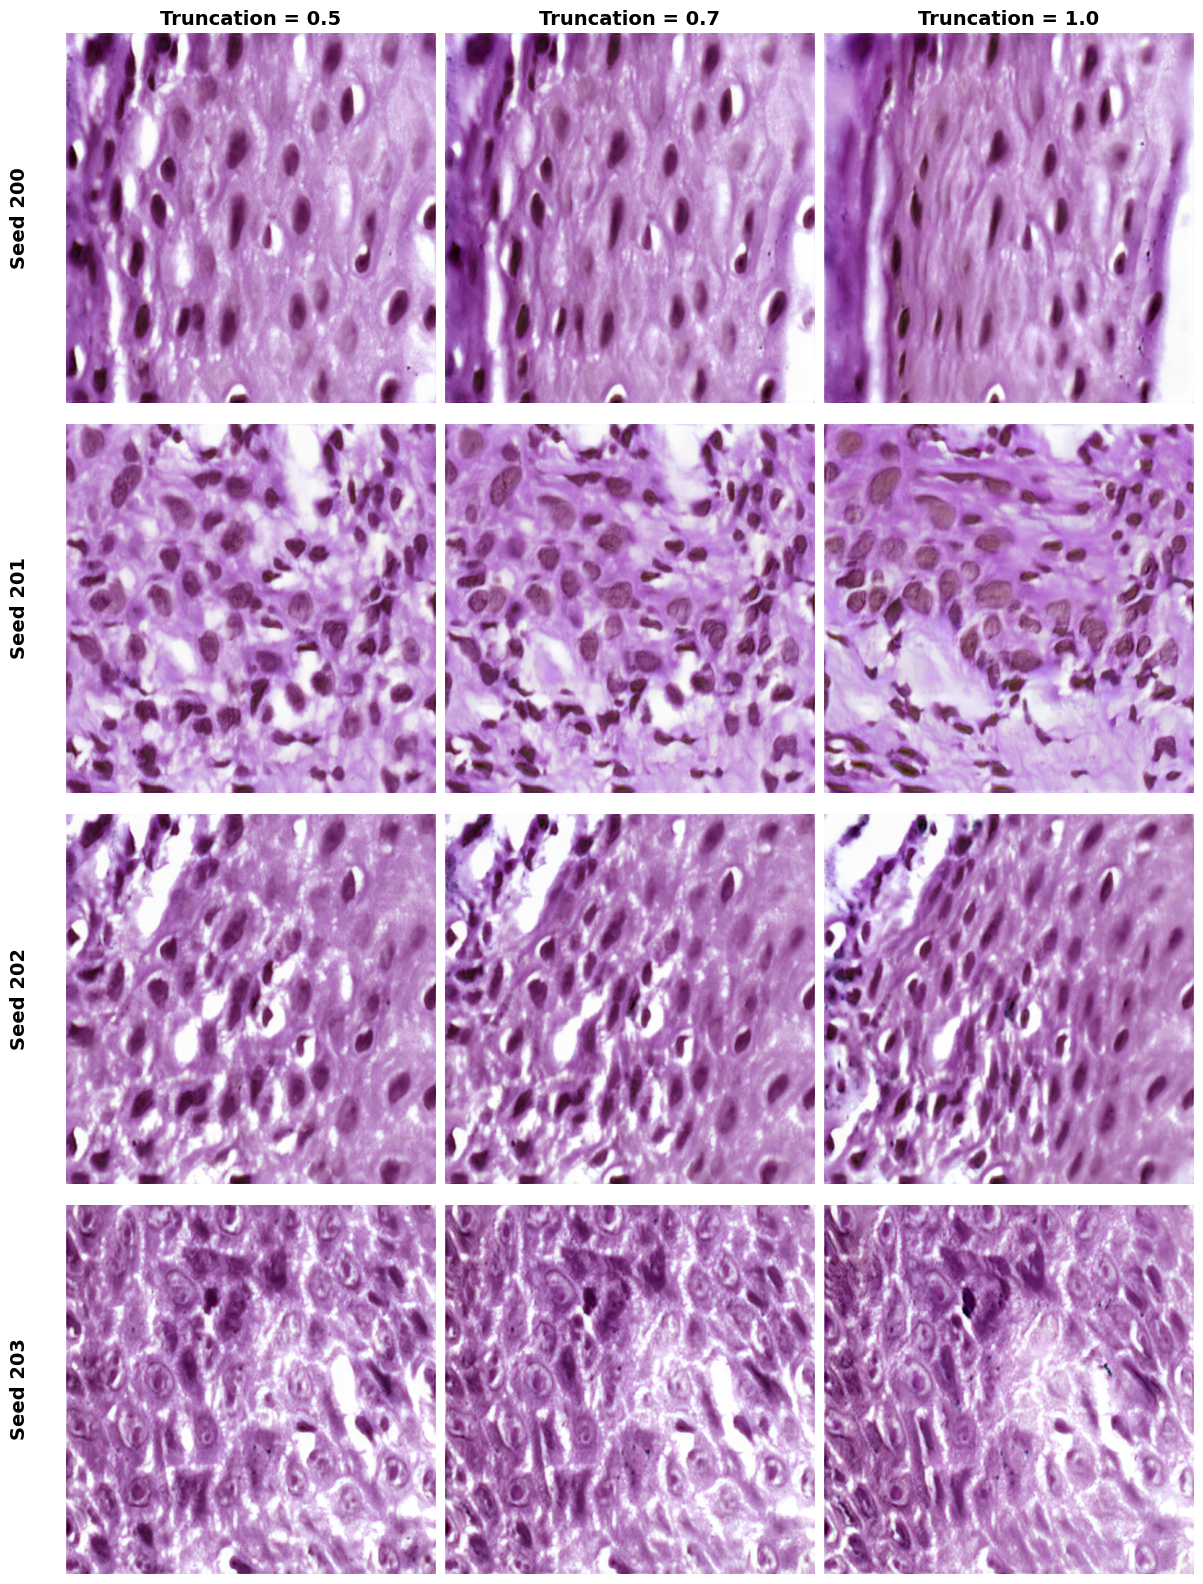

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define the truncations and a subset of your seeds to visualize
truncations = [0.5, 0.7, 1.0]
seeds_to_display = [200, 201, 202, 203] # Showing 4 seeds for a clean grid

# Set up the matplotlib figure
fig, axes = plt.subplots(len(seeds_to_display), len(truncations), figsize=(12, 4 * len(seeds_to_display)))

for row_idx, seed in enumerate(seeds_to_display):
    for col_idx, trunc in enumerate(truncations):
        # StyleGAN2-ADA saves files in the format 'seed0200.png'
        filename = f"seed{seed:04d}.png"
        img_path = f"/kaggle/working/truncation_sweep/trunc_{trunc}/{filename}"
        
        ax = axes[row_idx, col_idx]
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
            
        ax.axis('off') # Hide axes
        
        # Add column titles to the top row
        if row_idx == 0:
            ax.set_title(f"Truncation = {trunc}", fontsize=14, fontweight='bold')
        
        # Add row labels to the far left column
        if col_idx == 0:
            ax.text(-0.1, 0.5, f"Seed {seed}", va='center', ha='right', 
                    transform=ax.transAxes, fontsize=14, rotation=90, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import sys
import os
import torch
import numpy as np
import imageio
from tqdm import tqdm

# 1. Add the StyleGAN2-ADA directory to the Python path to import its modules
sys.path.append("/kaggle/input/notebooks/anil701/notebookd9384760a7/stylegan2-ada-pytorch")
import legacy
import dnnlib

# 2. Configuration
network_pkl = "/kaggle/working/network-snapshot-002800.pkl"
out_path = "/kaggle/working/latent_interpolation.mp4"
seeds = [200, 201, 202, 203, 200]  # Looping back to 200 creates a seamless looping video
class_idx = 0                      # Keeping class constant for smooth tissue transitions
truncation_psi = 0.7               # Using our identified "sweet spot"
fps = 30
frames_per_transition = 60         # 60 frames = 2 seconds per morph at 30 fps

# Set up device (1 GPU is perfectly fine for fast inference)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# 3. Load the pre-trained generator
print(f"Loading network from {network_pkl}...")
with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)['G_ema'].to(device)

# Set up the class label (if your dataset is conditional)
label = torch.zeros([1, G.c_dim], device=device)
if G.c_dim > 0:
    label[:, class_idx] = 1

# 4. Map random seeds ($z$) to the style latent space ($W$)
print("Mapping seeds to W space...")
ws = []
for seed in seeds:
    # Generate random noise vector z
    z = torch.from_numpy(np.random.RandomState(seed).randn(1, G.z_dim)).to(device)
    # Map z to w using the mapping network
    w = G.mapping(z, label, truncation_psi=truncation_psi)
    ws.append(w)

# 5. Interpolate and Generate Frames
video_frames = []
print("Synthesizing interpolation frames...")

for i in range(len(ws) - 1):
    w1 = ws[i]
    w2 = ws[i+1]
    
    # Smoothly morph from w1 to w2
    for step in tqdm(range(frames_per_transition), desc=f"Transition {i+1}/{len(ws)-1}"):
        alpha = step / float(frames_per_transition)
        
        # Linear interpolation in W space
        w_interp = w1 * (1 - alpha) + w2 * alpha
        
        # Synthesize the image from the interpolated W vector
        img = G.synthesis(w_interp, noise_mode='const')
        
        # Post-process the tensor to an RGB image
        img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
        video_frames.append(img[0].cpu().numpy())

# 6. Save the video
print(f"\nSaving MP4 video to {out_path}...")
imageio.mimsave(out_path, video_frames, fps=fps)
print("Done! You can now download and view 'latent_interpolation.mp4'.")

Loading network from /kaggle/working/network-snapshot-002800.pkl...
Mapping seeds to W space...
Setting up PyTorch plugin "bias_act_plugin"... 

📊 Raw Data Class Distribution ('oraldatarwa'):
---------------------------------------------
Class 'mdoscc': 2699 images
Class 'normal': 1045 images
Class 'osmf': 2095 images
Class 'pdoscc': 1599 images
Class 'wdoscc': 2790 images
---------------------------------------------
Total Images: 10228



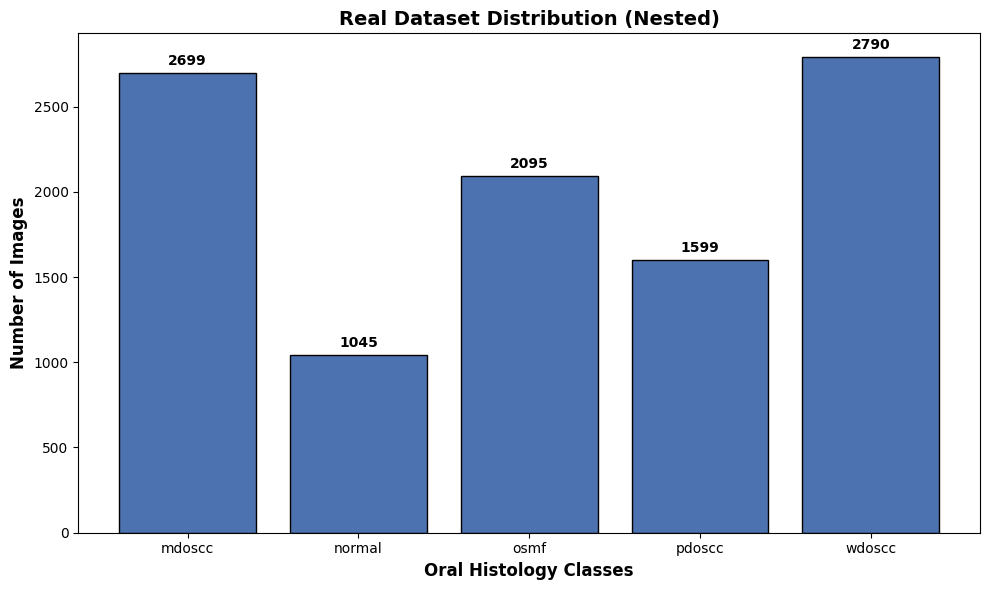

In [3]:
import os
import matplotlib.pyplot as plt

# The root directory of your dataset
raw_data_dir = "/kaggle/input/datasets/anil701/oraldatarwa" 

def check_raw_distribution_nested(data_path):
    if not os.path.exists(data_path):
        print(f"Error: The path '{data_path}' does not exist.")
        return

    class_counts = {}
    
    # Get the main class folders (mdoscc, normal, etc.)
    try:
        classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    except Exception as e:
        print(f"Error reading directory: {e}")
        return
         
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        file_count = 0
        
        # os.walk digs through all nested subfolders automatically
        for root, dirs, files in os.walk(class_path):
            # Filter to only count actual image files to be safe
            image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            file_count += len(image_files)
            
        class_counts[class_name] = file_count

    # Sort the dictionary alphabetically by class name
    class_counts = dict(sorted(class_counts.items(), key=lambda item: item[0]))

    # Print the text summary
    print("📊 Raw Data Class Distribution ('oraldatarwa'):")
    print("-" * 45)
    total_images = 0
    for class_name, count in class_counts.items():
        print(f"Class '{class_name}': {count} images")
        total_images += count
    print("-" * 45)
    print(f"Total Images: {total_images}\n")

    # Generate the bar chart
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='#4C72B0', edgecolor='black')
    
    plt.xlabel('Oral Histology Classes', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
    plt.title('Real Dataset Distribution (Nested)', fontsize=14, fontweight='bold')
    
    # Add the exact count numbers on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(class_counts.values()) * 0.01) if max(class_counts.values()) > 0 else 0.1, 
                 int(yval), ha='center', va='bottom', fontweight='bold')
                 
    plt.tight_layout()
    plt.show()

# Execute the function
check_raw_distribution_nested(raw_data_dir)